
# Synthetic Image Detection using Gradient Fields

This Colab notebook lets you:

1. Upload an image
2. Convert it to luminance
3. Compute spatial gradients
4. Build the gradient covariance matrix
5. Visualize a PCA-style gradient-field graph
6. Produce a **heuristic** prediction: **likely real**, **likely fake**, or **ambiguous**

**Important:** this is **not** a validated forensic detector. The final label is based on an interpretable hand-crafted rule using gradient statistics, not a trained benchmarked model.


In [1]:

# If running in Colab, uncomment this if needed:
# !pip install pillow matplotlib numpy

import io
import math
import numpy as np
import matplotlib.pyplot as plt

from PIL import Image

try:
    from google.colab import files
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

plt.rcParams["figure.dpi"] = 140


In [2]:

def rgb_to_luminance(rgb):
    rgb = rgb.astype(np.float32) / 255.0
    r = rgb[..., 0]
    g = rgb[..., 1]
    b = rgb[..., 2]
    return 0.2126 * r + 0.7152 * g + 0.0722 * b

def compute_gradients(lum):
    gy, gx = np.gradient(lum)
    return gx, gy

def build_gradient_matrix(gx, gy):
    return np.column_stack([gx.ravel(), gy.ravel()])

def covariance_from_gradients(gx, gy):
    M = build_gradient_matrix(gx, gy)
    N = M.shape[0]
    C = (M.T @ M) / max(N, 1)
    return C, M

def eig2x2(C):
    vals, vecs = np.linalg.eigh(C)
    order = np.argsort(vals)[::-1]
    vals = vals[order]
    vecs = vecs[:, order]
    return vals, vecs

def analyze_image_array(rgb, max_dim=700):
    h, w = rgb.shape[:2]
    scale = min(1.0, max_dim / max(h, w))
    if scale < 1.0:
        new_w = int(round(w * scale))
        new_h = int(round(h * scale))
        rgb = np.array(Image.fromarray(rgb).resize((new_w, new_h), Image.Resampling.LANCZOS))

    lum = rgb_to_luminance(rgb)
    gx, gy = compute_gradients(lum)
    grad_mag = np.sqrt(gx**2 + gy**2)

    C, M = covariance_from_gradients(gx, gy)
    eigvals, eigvecs = eig2x2(C)

    lambda1, lambda2 = eigvals
    v1 = eigvecs[:, 0]
    v2 = eigvecs[:, 1]

    trace = float(np.trace(C))
    det = float(np.linalg.det(C))
    anisotropy = float((lambda1 - lambda2) / (lambda1 + lambda2 + 1e-12))
    ratio = float(lambda1 / (lambda2 + 1e-12))

    features = {
        "cxx": float(C[0, 0]),
        "cyy": float(C[1, 1]),
        "cxy": float(C[0, 1]),
        "trace": trace,
        "det": det,
        "lambda1": float(lambda1),
        "lambda2": float(lambda2),
        "anisotropy": anisotropy,
        "ratio": ratio,
    }

    return {
        "rgb": rgb,
        "luminance": lum,
        "gx": gx,
        "gy": gy,
        "grad_mag": grad_mag,
        "M": M,
        "C": C,
        "eigvals": eigvals,
        "eigvecs": eigvecs,
        "v1": v1,
        "v2": v2,
        "features": features,
    }


In [8]:


# Hand-crafted score. Higher means "more likely fake-looking".
# This is only a lightweight interpretable heuristic.
def heuristic_fake_score(features):
    anis = features["anisotropy"]
    ratio = features["ratio"]
    trace = features["trace"]
    det = features["det"]
    cxy = abs(features["cxy"])

    score = 0.0

    # More isotropic fields can look less physically coherent
    if anis < 0.12:
        score += 1.2
    elif anis < 0.18:
        score += 0.8
    elif anis < 0.24:
        score += 0.3

    # Weak principal direction separation
    if ratio < 1.20:
        score += 1.0
    elif ratio < 1.50:
        score += 0.6
    elif ratio < 1.90:
        score += 0.2

    # More total micro-structure energy can indicate synthetic over-texturing
    if trace > 0.010:
        score += 1.0
    elif trace > 0.005:
        score += 0.6
    elif trace > 0.002:
        score += 0.25

    # Low cross-correlation between x/y gradients may accompany noisy isotropic structure
    if cxy < 0.00002:
        score += 0.35

    # Slight stabilization term from determinant
    if det < 1e-8:
        score += 0.25

    return float(score)

def classify_image(features):
    score = heuristic_fake_score(features)

    if score >= 2.2:
        label = "LIKELY FAKE"
        color = "crimson"
    elif score <= 1.0:
        label = "LIKELY REAL"
        color = "seagreen"
    else:
        label = "AMBIGUOUS"
        color = "darkorange"

    return {"score": score, "label": label, "color": color}


In [32]:
def plot_infographic_style(result, classification, sample_size=3500):
    rgb = result["rgb"]
    lum = result["luminance"]
    grad_mag = result["grad_mag"]
    M = result["M"]
    C = result["C"]
    eigvals = result["eigvals"]
    v1 = result["v1"]
    v2 = result["v2"]
    f = result["features"]

    idx = np.linspace(0, len(M) - 1, min(sample_size, len(M))).astype(int)
    pts = M[idx]

    fig = plt.figure(figsize=(10, 11), constrained_layout=True)
    gs = fig.add_gridspec(
        nrows=3, ncols=2,
        height_ratios=[0.4, 2.8, 2.6],
        wspace=0.05
    )

    ax_title = fig.add_subplot(gs[0, :])
    ax_title.axis("off")
    ax_title.text(
        0.5, 0.5,
        "Synthetic Image Detection using Gradient Fields",
        ha="center", va="center", fontsize=22, fontweight="bold"
    )

    ax_real = fig.add_subplot(gs[1, 0])
    ax_grad = fig.add_subplot(gs[1, 1])

    ax_real.set_facecolor("#cfe7fb")
    ax_grad.set_facecolor("#f6d6dc")

    for ax, title in [(ax_real, "Image"), (ax_grad, "Gradient")]:
        ax.set_xticks([])
        ax.set_yticks([])
        for s in ax.spines.values():
            s.set_visible(False)
        ax.set_title(title, fontsize=26, fontweight="bold", pad=10, fontfamily="serif")

    ax_real.imshow(rgb)
    ax_grad.imshow(grad_mag, cmap="gray")

    ax_scatter = fig.add_subplot(gs[2, :])
    ax_scatter.set_facecolor("#f8fafc")
    ax_scatter.scatter(pts[:, 0], pts[:, 1], s=5, alpha=0.18, color="#475569")
    ax_scatter.axhline(0, color="#94a3b8", lw=1)
    ax_scatter.axvline(0, color="#94a3b8", lw=1)
    ax_scatter.set_title("Gradient Field PCA Projection", fontsize=17, fontweight="bold")
    ax_scatter.set_xlabel("Gx")
    ax_scatter.set_ylabel("Gy")

    max_scale = max(np.max(np.abs(pts)), 1e-6)
    r1 = np.sqrt(max(eigvals[0], 0)) * 3.0
    r2 = np.sqrt(max(eigvals[1], 0)) * 3.0

    line1 = np.vstack([-v1 * r1, v1 * r1])
    line2 = np.vstack([-v2 * r2, v2 * r2])

    ax_scatter.plot(line1[:, 0], line1[:, 1], color="#eab308", lw=3, label="PC1")
    ax_scatter.plot(line2[:, 0], line2[:, 1], color="#8b5cf6", lw=3, label="PC2")

    theta = np.linspace(0, 2 * np.pi, 400)
    ellipse = np.column_stack([r1 * np.cos(theta), r2 * np.sin(theta)])
    basis = np.column_stack([v1, v2])
    ellipse_xy = ellipse @ basis.T
    ax_scatter.plot(ellipse_xy[:, 0], ellipse_xy[:, 1], color="#db2777", lw=2)

    pad = max_scale * 0.15
    ax_scatter.set_xlim(-max_scale - pad, max_scale + pad)
    ax_scatter.set_ylim(-max_scale - pad, max_scale + pad)
    ax_scatter.legend(frameon=False, loc="upper right")

    score = classification["score"]
    label = classification["label"]
    ax_scatter.text(
        0.02, 0.98,
        f"Prediction: {label}\nScore: {score:.3f}",
        transform=ax_scatter.transAxes,
        va="top", ha="left", fontsize=12,
        bbox=dict(facecolor="white", alpha=0.9, edgecolor="#cbd5e1")
    )

    plt.show()

    print("Prediction:", label)
    print("Heuristic fake score:", round(score, 4))
    print("Anisotropy:", round(f["anisotropy"], 4))
    print("Principal ratio:", round(f["ratio"], 4))
    print("Trace:", round(f["trace"], 6))
    print("Determinant:", round(f["det"], 8))
    print("Covariance matrix:")
    print(C)

Saving dog.jpg to dog (9).jpg


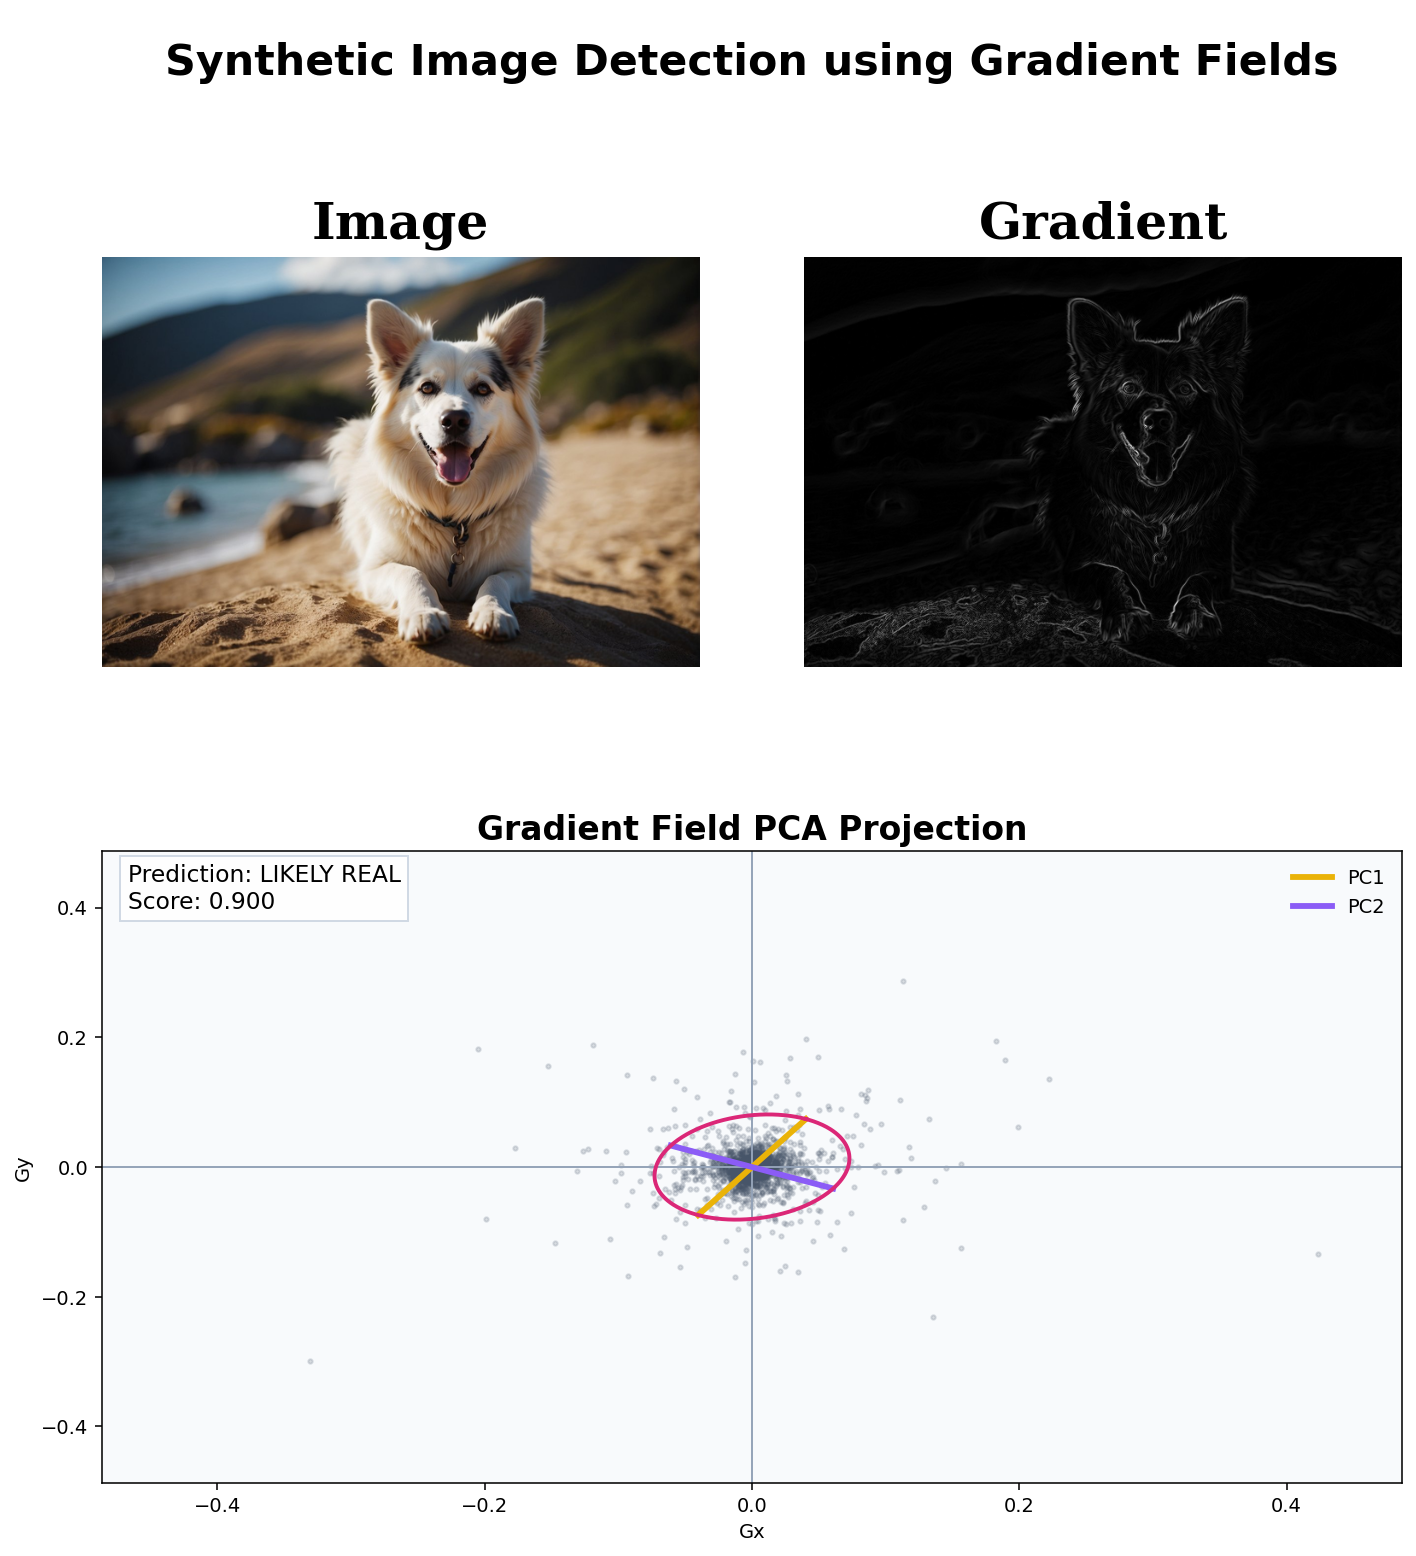

Prediction: LIKELY REAL
Heuristic fake score: 0.9
Anisotropy: 0.1953
Principal ratio: 1.4855
Trace: 0.001321
Determinant: 4.2e-07
Covariance matrix:
[[0.00059067 0.00010844]
 [0.00010844 0.00073055]]


In [33]:

# Upload an image in Colab, or set a local path if running elsewhere.

if IN_COLAB:
    uploaded = files.upload()
    if not uploaded:
        raise ValueError("No file uploaded.")
    first_name = next(iter(uploaded))
    image_bytes = uploaded[first_name]
    image = Image.open(io.BytesIO(image_bytes)).convert("RGB")
else:
    image_path = "your_image.jpg"  # change this if running outside Colab
    image = Image.open(image_path).convert("RGB")

rgb = np.array(image)
result = analyze_image_array(rgb)
classification = classify_image(result["features"])
plot_infographic_style(result, classification)



## Notes on the prediction

The notebook includes a built-in **fake/not fake decision rule**, but it is a **heuristic**, not a trained detector. That means:

- it can be useful for quick visual inspection
- it is lightweight and interpretable
- it can definitely be wrong
- it should not be treated as proof of authenticity

For a stronger detector, the next step would be to collect a dataset of real and AI-generated images and train a small model on gradient-based features.
